# Experiment 2
## Text Preprocessing and Morphological Analysis on Customer Reviews

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Natural Language Processing Lab

### Aim
To take a text document of customer reviews and perform complete preprocessing on it :

A) Remove punctuation marks and special characters  
B) Convert all the words into lower case  
C) Remove the commonly used stop words  
D) Apply stemming to reduce the words to their root form  
E) Perform spelling correction  
F) Expand the contractions like don't to do not, can't to cannot  
G) Calculate and compare the number of unique words before and after lemmatization

### Theory
Raw text written by customers is very noisy. The same word comes in many forms (Good, good, GOOD), spellings are wrong, contractions are used, and there is punctuation everywhere. If we give this directly to a model then "good" and "Good" are treated as two diffrent words. Preprocessing brings all of this to one standard form.

**Morphological analysis** means studying the structure of a word, that is the root and the extra parts attached to it. Two techniques are used for this :

**Stemming** just chops the ending using fixed rules. It is fast but the output is not always a real word, like "studies" becomes "studi" and "delivery" becomes "deliveri".

**Lemmatization** uses a dictionary (WordNet) and the part of speech of the word, so the output is always a proper word. "studies" becomes "study" and "better" becomes "good". It is slower than stemming but the result is meaningful.

**Order of the steps is important.** Contractions must be expanded first, because if punctuation is removed first then "don't" becomes "dont" and it can never be expanded properly. Spelling correction is done after cleaning, otherwise the punctuation confuses the spell checker.

### 1. Libraries

In [ ]:

import re
import string
import nltk 
import contractions #expand short forms 
from spellchecker import SpellChecker

# nltk data needed for this experiment
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print("all libraries loaded")

all libraries loaded


### 2. The text document
Making a file reviews.txt with 20 customer reviews. I have kept the spelling mistakes, contractions and special characters as it is, because that is what we have to clean.

In [2]:
reviews = [
    "The prodcut arrived two days early and I'm very happy with it!!! Excelent build qualtiy for the price.",
    "I didn't like the camara at all. The pictur quality is terible in low light @night.",
    "Battery backup is amazing... it easily lasts 2 days on a single charge. Definately worth Rs.15,000.",
    "Worst experiance ever!!! The packge was damaged and the screen wasn't working properly.",
    "Customer servce is very freindly, they replaced my defective unit within 3 days. Thanks team :)",
    "It's a decent phone but the speakers aren't loud enough. You'll need earphones in a noisy room.",
    "I recieved the wrong colour. I don't understand how they can make such a basic mistake.",
    "The shoes are super comfertable and I've been wearing them daily for running. Highly recommended!!",
    "Delivery was deliverd on time but the box was opened. Everything inside was fine though.",
    "Dont waste your monney on this. The material feels cheap and it broke within a week :(",
    "Awsome laptop for students. It's fast, light and the keyboard is really comfortable to type on.",
    "The washing machine is good but the installation guy didn't come for 5 days. Very poor followup.",
    "Bought this for my mother & she loves it. The buttons are big and easy to use for elderly people.",
    "Product is okay okay. Not great not bad. For the price you're paying I expected better finishing.",
    "I can't believe how good this trimmer is at this price!! Battery lasts long & the blades are sharp.",
    "The book pages are of low qualtiy paper and few pages were missing. Very dissapointed with seller.",
    "Excellent sound quality, deep bass and the noise cancellation actually works while travelling.",
    "They're saying 1 year warranty but the service center refused to repair it. Totally misleading %$#.",
    "My order was cancelled automatically without any reason. I've mailed them but no response till now.",
    "Simple, useful and cheap. Does exactly what it says. Would buy again from this brand 100%.",
]

with open("reviews.txt", "w") as f:
    for r in reviews:
        f.write(r + "\n")

print("reviews.txt created with", len(reviews), "reviews")

reviews.txt created with 20 reviews


In [3]:
# reading the document back
with open("reviews.txt", "r") as f:
    text = f.read()

print("total characters :", len(text))
print()
print(text[:400])

total characters : 1904

The prodcut arrived two days early and I'm very happy with it!!! Excelent build qualtiy for the price.
I didn't like the camara at all. The pictur quality is terible in low light @night.
Battery backup is amazing... it easily lasts 2 days on a single charge. Definately worth Rs.15,000.
Worst experiance ever!!! The packge was damaged and the screen wasn't working properly.
Customer servce is very f


Keeping a copy of the original text so that at the end we can compare original vs cleaned.

In [4]:
original_text = text
original_tokens = word_tokenize(original_text)
print("tokens in the raw text :", len(original_tokens))
print("unique tokens in raw text :", len(set(original_tokens)))

tokens in the raw text : 396
unique tokens in raw text : 237


### 3. (F) Expanding the contractions
Doing this step first, before removing the punctuation, because contractions need the apostrophe.

In [5]:
print("before :", text[:200])
print()

text = contractions.fix(text)

print("after  :", text[:200])

before : The prodcut arrived two days early and I'm very happy with it!!! Excelent build qualtiy for the price.
I didn't like the camara at all. The pictur quality is terible in low light @night.
Battery backu

after  : The prodcut arrived two days early and I am very happy with it!!! Excelent build qualtiy for the price.
I did not like the camara at all. The pictur quality is terible in low light @night.
Battery bac


In [6]:
# small check on a few examples
for w in ["don't", "can't", "I've", "they're", "wasn't", "you'll"]:
    print(w, "=>", contractions.fix(w))

don't => do not
can't => cannot
I've => I have
they're => they are
wasn't => was not
you'll => you will


### 4. (B) Converting to lower case
So that Good, good and GOOD are counted as the same word.

In [7]:
text = text.lower()
print(text[:250])

the prodcut arrived two days early and i am very happy with it!!! excelent build qualtiy for the price.
i did not like the camara at all. the pictur quality is terible in low light @night.
battery backup is amazing... it easily lasts 2 days on a sing


### 5. (A) Removing punctuation and special characters
First removing the urls and numbers, then everything which is not a letter or a space. `string.punctuation` has all the punctuation marks, but here regex is easier because it also removes symbols like ₹ and emojis.

In [8]:
print("punctuation marks :", string.punctuation)

text = re.sub(r"http\S+|www\.\S+", " ", text)    # links
text = re.sub(r"\d+", " ", text)                  # numbers
text = re.sub(r"[^a-z\s]", " ", text)             # anything which is not a letter
text = re.sub(r"\s+", " ", text).strip()          # extra spaces

print()
print(text[:300])

punctuation marks : !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

the prodcut arrived two days early and i am very happy with it excelent build qualtiy for the price i did not like the camara at all the pictur quality is terible in low light night battery backup is amazing it easily lasts days on a single charge definately worth rs worst experiance ever the packge


### 6. Tokenization
Breaking the cleaned text into words.

In [9]:
tokens = word_tokenize(text)

print("total tokens :", len(tokens))
print("unique tokens :", len(set(tokens)))
print()
print(tokens[:25])

total tokens : 331
unique tokens : 207

['the', 'prodcut', 'arrived', 'two', 'days', 'early', 'and', 'i', 'am', 'very', 'happy', 'with', 'it', 'excelent', 'build', 'qualtiy', 'for', 'the', 'price', 'i', 'did', 'not', 'like', 'the', 'camara']


### 7. (E) Spelling correction
pyspellchecker compares every word with its dictionary and suggests the closest correct word. It is slow if the text is big, so i am correcting only the words which it marks as unknown.

In [10]:
spell = SpellChecker()

wrong = spell.unknown(tokens)
print("words which are not in the dictionary :", len(wrong))
print(sorted(list(wrong))[:20])

words which are not in the dictionary : 18
['awsome', 'camara', 'colour', 'comfertable', 'definately', 'deliverd', 'dissapointed', 'excelent', 'experiance', 'freindly', 'monney', 'packge', 'pictur', 'prodcut', 'qualtiy', 'recieved', 'servce', 'terible']


In [11]:
corrected = []
changes = []

for w in tokens:
    if w in wrong:
        fix = spell.correction(w)
        if fix is None:
            fix = w
        if fix != w:
            changes.append((w, fix))
        corrected.append(fix)
    else:
        corrected.append(w)

print("words corrected :", len(changes))
print()
for a, b in changes[:15]:
    print(a, "=>", b)

words corrected : 19

prodcut => product
excelent => excellent
qualtiy => quality
camara => camera
pictur => picture
terible => terrible
definately => definitely
experiance => experience
packge => package
servce => serve
freindly => friendly
recieved => received
colour => color
comfertable => comfortable
deliverd => deliver


In [12]:
tokens = corrected
print("tokens after spelling correction :", len(tokens))

tokens after spelling correction : 331


Spell checkers are not perfect, few mistakes i noticed in the output above :
- servce became **serve** but the correct word was service
- deliverd became **deliver** instead of delivered
- colour became **color**, it is not a mistake, it is just british spelling

So on real data this step should be used carefully, sometimes it changes correct words also.

### 8. (C) Removing stop words
Words like is, the, was, and do not carry much meaning so they are removed.

In [13]:
stop_words = set(stopwords.words("english"))
print("total stop words in nltk :", len(stop_words))
print(sorted(list(stop_words))[:20])

total stop words in nltk : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [14]:
filtered = [w for w in tokens if w not in stop_words and len(w) > 2]

print("tokens before removing stop words :", len(tokens))
print("tokens after removing stop words  :", len(filtered))
print("removed :", len(tokens) - len(filtered))
print()
print(filtered[:25])

tokens before removing stop words : 331
tokens after removing stop words  : 177
removed : 154

['product', 'arrived', 'two', 'days', 'early', 'happy', 'excellent', 'build', 'quality', 'price', 'like', 'camera', 'picture', 'quality', 'terrible', 'low', 'light', 'night', 'battery', 'backup', 'amazing', 'easily', 'lasts', 'days', 'single']


### 9. (D) Stemming
Porter stemmer is used. It only cuts the suffix so many times the output is not a real english word.

In [15]:
ps = PorterStemmer()
stemmed = [ps.stem(w) for w in filtered]

print("word            stem")
for w, s in list(zip(filtered, stemmed))[:15]:
    print(w.ljust(15), s)

word            stem
product         product
arrived         arriv
two             two
days            day
early           earli
happy           happi
excellent       excel
build           build
quality         qualiti
price           price
like            like
camera          camera
picture         pictur
quality         qualiti
terrible        terribl


In [16]:
print("unique words before stemming :", len(set(filtered)))
print("unique words after stemming  :", len(set(stemmed)))

unique words before stemming : 157
unique words after stemming  : 153


### 10. Lemmatization
WordNet lemmatizer needs to know the part of speech, otherwise it treats everything as a noun and words like "arrived" stay as it is. So first the pos tag is taken from nltk and then converted into the format which wordnet understands.

In [25]:
from nltk.corpus import wordnet

def get_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

lem = WordNetLemmatizer()
tagged = nltk.pos_tag(filtered)

lemmatized = [lem.lemmatize(w, get_pos(t)) for w, t in tagged]

print("word            pos   lemma")
for (w, t), l in list(zip(tagged, lemmatized))[:15]:
    print(w.ljust(15), t.ljust(5), l)

word            pos   lemma
product         NN    product
arrived         VBD   arrive
two             CD    two
days            NNS   day
early           RB    early
happy           JJ    happy
excellent       JJ    excellent
build           NN    build
quality         NN    quality
price           NN    price
like            IN    like
camera          NN    camera
picture         NN    picture
quality         NN    quality
terrible        JJ    terrible


Difference between stemming and lemmatization on the same words.

In [18]:
print("word          stem          lemma")
seen = []
for w, s, l in zip(filtered, stemmed, lemmatized):
    if s != l and w not in seen:
        seen.append(w)
        print(w.ljust(13), s.ljust(13), l)
    if len(seen) == 12:
        break

word          stem          lemma
arrived       arriv         arrive
early         earli         early
happy         happi         happy
excellent     excel         excellent
quality       qualiti       quality
picture       pictur        picture
terrible      terribl       terrible
battery       batteri       battery
amazing       amaz          amaze
easily        easili        easily
single        singl         single
charge        charg         charge


### 11. (G) Unique words before and after lemmatization

In [19]:
before = set(filtered)
after = set(lemmatized)

print("total words                      :", len(filtered))
print("unique words BEFORE lemmatization :", len(before))
print("unique words AFTER  lemmatization :", len(after))
print("reduction                        :", len(before) - len(after))
print("reduction in percent             :", round((len(before) - len(after)) / len(before) * 100, 2), "%")

total words                      : 177
unique words BEFORE lemmatization : 157
unique words AFTER  lemmatization : 153
reduction                        : 4
reduction in percent             : 2.55 %


Which words actually got merged.

In [20]:
merged = {}
for w, l in zip(filtered, lemmatized):
    if w != l:
        merged.setdefault(l, set()).add(w)

count = 0
for root in merged:
    print(root, "<-", merged[root])
    count += 1
    if count == 12:
        break

arrive <- {'arrived'}
day <- {'days'}
amaze <- {'amazing'}
last <- {'lasts'}
bad <- {'worst'}
damage <- {'damaged'}
work <- {'working', 'works'}
replace <- {'replaced'}
speaker <- {'speakers'}
earphone <- {'earphones'}
receive <- {'received'}
shoe <- {'shoes'}


Both stemming and lemmatization brought the count to 153, but they did not group the same words. Printing which words got merged together in each case.

In [21]:
def merge_groups(words, roots):
    groups = {}
    for w, r in zip(words, roots):
        groups.setdefault(r, set()).add(w)
    return {r: g for r, g in groups.items() if len(g) > 1}

print("merged by STEMMING :")
for r, g in merge_groups(filtered, stemmed).items():
    print("  ", r, "<-", g)

print()
print("merged by LEMMATIZATION :")
for r, g in merge_groups(filtered, lemmatized).items():
    print("  ", r, "<-", g)

merged by STEMMING :
   work <- {'working', 'works'}
   use <- {'useful', 'use'}
   cancel <- {'cancellation', 'cancelled'}
   say <- {'says', 'saying'}

merged by LEMMATIZATION :
   bad <- {'bad', 'worst'}
   work <- {'working', 'works'}
   buy <- {'bought', 'buy'}
   say <- {'says', 'saying'}


In [22]:
# the stems which are not real english words
not_words = sorted(set([s for s in stemmed if s not in set(lemmatized) and len(s) > 3]))
print(not_words[:20])

['actual', 'amaz', 'arriv', 'automat', 'awesom', 'batteri', 'believ', 'better', 'bought', 'charg', 'comfort', 'custom', 'daili', 'damag', 'defect', 'definit', 'deliv', 'deliveri', 'disappoint', 'earli']


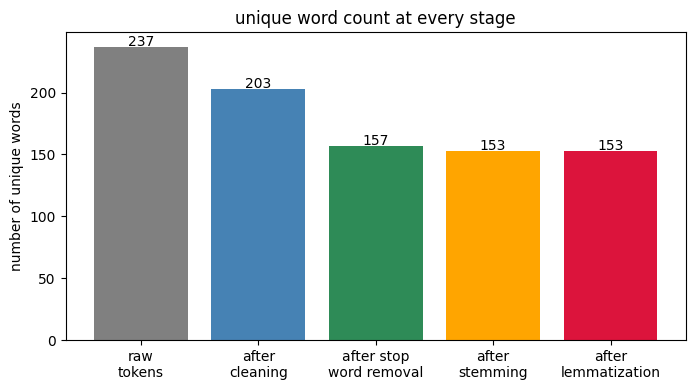

In [23]:
import matplotlib.pyplot as plt

labels = ["raw\ntokens", "after\ncleaning", "after stop\nword removal", "after\nstemming", "after\nlemmatization"]
values = [len(set(original_tokens)), len(set(tokens)), len(before), len(set(stemmed)), len(after)]

plt.figure(figsize=(8,4))
bars = plt.bar(labels, values, color=['grey', 'steelblue', 'seagreen', 'orange', 'crimson'])
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha='center')
plt.ylabel("number of unique words")
plt.title("unique word count at every stage")
plt.show()

### Result

All the seven operations were performed on the customer reviews document.

| Step | What it did |
|---|---|
| F. Contraction expansion | don't became do not, can't became cannot |
| B. Lower case | Good and good treated as one word |
| A. Punctuation and special characters | removed !!! ??? @ % and also links and numbers |
| E. Spelling correction | prodcut became product, recieved became received |
| C. Stop word removal | removed is, the, was, and, for |
| D. Stemming | delivery became deliveri, quality became qualiti |
| G. Lemmatization | pages became page, arrived became arrive |

**Observation :** unique words came down from 157 to 153 by lemmatization, which is only 2.55 percent. The reduction looks small because most of the inflected words are appearing only once in these reviews, so changing "arrived" to "arrive" does not reduce the count, it only changes the word. The count goes down only when two diffrent forms come to the same root, like works and working both becoming work.

Interesting thing is stemming also gave 153, same number, but the two are not doing the same job :
- stemming merged use + useful and cancelled + cancellation, which is wrong because their meaning is not same
- lemmatization merged worst with bad and bought with buy, which stemming could not do
- stemming output has words like qualiti, deliveri, batteri, experi, terribl which are not english words at all

So the counts are equal but lemmatization output is much more meaningful.

Also the order of the steps really matters. When i removed the punctuation before expanding contractions, "don't" became "dont" and the contraction library could not expand it anymore.

### what i learned
Preprocessing is doing most of the work in NLP. After all the steps the vocabulary became much smaller than the raw text, which means the same information is now in a much cleaner form.